In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout

In [3]:

train_dir = "C:\\Users\\HP\\Desktop\\internship\\face\\train"
test_dir = "C:\\Users\\HP\\Desktop\\internship\\face\\test"

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [5]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)


In [6]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48,48),
    color_mode="grayscale",
    batch_size=64,
    class_mode='categorical'
)


Found 28709 images belonging to 7 classes.


In [7]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(48,48),
    color_mode="grayscale",
    batch_size=64,
    class_mode='categorical'
)

Found 7178 images belonging to 7 classes.


In [8]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',
                 input_shape=(48,48,1)))

model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(256,activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(7,activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


c:\Users\HP\Desktop\internship\env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=25
)

model.save("../models/emotion_model.h5")

print("Model Saved")

Epoch 1/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 50s 107ms/step - accuracy: 0.2659 - loss: 1.7789 - val_accuracy: 0.3288 - val_loss: 1.6724
Epoch 2/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 33s 74ms/step - accuracy: 0.3468 - loss: 1.6440 - val_accuracy: 0.4323 - val_loss: 1.4973
Epoch 3/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 31s 68ms/step - accuracy: 0.4154 - loss: 1.5143 - val_accuracy: 0.4769 - val_loss: 1.3690
Epoch 4/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 31s 68ms/step - accuracy: 0.4539 - loss: 1.4326 - val_accuracy: 0.4975 - val_loss: 1.3073
Epoch 5/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 31s 68ms/step - accuracy: 0.4708 - loss: 1.3875 - val_accuracy: 0.5065 - val_loss: 1.2824
Epoch 6/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.4821 - loss: 1.3559 - val_accuracy: 0.5146 - val_loss: 1.2723
Epoch 7/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 36s 80ms/step - accuracy: 0.4959 - loss: 1.3270 - val_accuracy: 0.5244 - val_loss: 1.2369
Epoch 8/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 41s 92ms/step - accuracy: 0.5015 - loss: 1.3075 -

Model Saved


In [12]:
model.save("emotion_model.keras")

c:\Users\HP\Desktop\internship\env\Lib\site-packages\keras\src\saving\saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'rm_sprop_1', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Press 'q' to quit


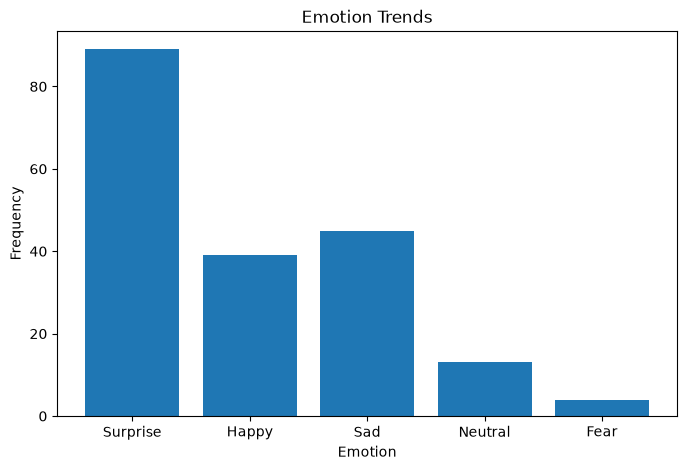

In [2]:
import cv2
import numpy as np
import tensorflow as tf
from collections import Counter
import matplotlib.pyplot as plt

# ===========================
# Load Trained Model
# ===========================
model = tf.keras.models.load_model("C:\\Users\\HP\\Desktop\\internship\\env\\emotion_model.keras")

# Emotion Labels (FER2013)
emotion_labels = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Sad",
    "Surprise",
    "Neutral"
]

# Store emotion history
emotion_history = []

# Load Face Detector
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

# Webcam
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Cannot open webcam")
    exit()

print("Press 'q' to quit")

while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame = cv2.flip(frame, 1)

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.3,
        minNeighbors=5,
        minSize=(40,40)
    )

    for (x, y, w, h) in faces:

        roi = gray[y:y+h, x:x+w]

        roi = cv2.resize(roi, (48,48))

        roi = roi.astype("float32") / 255.0

        roi = np.expand_dims(roi, axis=-1)

        roi = np.expand_dims(roi, axis=0)

        prediction = model.predict(roi, verbose=0)

        confidence = np.max(prediction)

        emotion = emotion_labels[np.argmax(prediction)]

        emotion_history.append(emotion)

        # Rectangle around face
        cv2.rectangle(
            frame,
            (x,y),
            (x+w,y+h),
            (0,255,0),
            2
        )

        label = f"{emotion} ({confidence*100:.2f}%)"

        cv2.putText(
            frame,
            label,
            (x,y-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0,255,255),
            2
        )

    cv2.imshow("Real-Time Emotion Detection", frame)

    key = cv2.waitKey(1)

    if key == ord('q'):
        break

cap.release()

cv2.destroyAllWindows()

# ==========================
# Emotion Trend Graph
# ==========================

if len(emotion_history) > 0:

    counts = Counter(emotion_history)

    plt.figure(figsize=(8,5))

    plt.bar(counts.keys(), counts.values())

    plt.title("Emotion Trends")

    plt.xlabel("Emotion")

    plt.ylabel("Frequency")

    plt.show()